<a href="https://colab.research.google.com/github/ManosHatzi5/Digit-09-DNN-4834/blob/main/MNIST_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

# Setting Environment Seeds

Seeds enable the reproduction of the experiments.

In [2]:
random.seed(0)
np.random.seed(seed=0)
tf.random.set_seed(seed=0)

# Load MNIST Dataset using Tensorflow

In [ ]:
(x_train, y_train), (x_test, y_test ) = tf.keras.datasets.mnist.load_data()
x_train.shape, y_train.shape, x_test.shape, y_test.shape

print(
    f'Training Size - Inputs:{x_train.shape}, Targets:{y_train.shape}'
    f'\nTest Size - Inputs:{x_test.shape}, Targets:{y_test.shape}'
)

# Displaying Random Digits

In [4]:
rows = 5
digits_per_row = 5

In [ ]:
fig, axes = plt.subplots(nrows=rows, ncols=digits_per_row, figsize=(6, 6))
axes = axes.flatten()

# Selecting random ids from 0 to 60000
total_digits = rows*digits_per_row
random_ids= np.random.choice(x_train.shape[0], total_digits, replace=False)

# Plotting the selected digits.
for i, ax in enumerate(axes):
    idx = random_ids[i]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(f'Class: {y_train[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
x_train = x_train.reshape((60000, 784))
y_train = tf.one_hot(y_train, depth=10)
x_test = x_test.reshape((10000, 784))
y_test = tf.one_hot(y_test, depth=10)

print(
    f'Training Size - Inputs:{x_train.shape}, Targets:{y_train.shape}'
    f'\nTest Size - Inputs:{x_test.shape}, Targets:{y_test.shape}'
)

Training Size - Inputs:(60000, 784), Targets:(60000, 10)
Test Size - Inputs:(10000, 784), Targets:(10000, 10)


In [7]:
activation = 'tanh'
loss = 'categorical_crossentropy' # Do not change this loss function.
metrics = ['accuracy']
learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate) # Do not change this optimizer.
epochs = 10

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,), name='input'),
    tf.keras.layers.Dense(units=256, activation=activation, name='hidden-1'),
    tf.keras.layers.Dense(units=256, activation=activation, name='hidden-2'),
    tf.keras.layers.Dense(units=10, activation='softmax', name='outputs') # Do not change this activation function.
])
model.summary(expand_nested=True)

In [ ]:
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
history = model.fit(
    x=x_train,
    y=y_train,
    epochs=epochs,
    validation_data=(x_test, y_test)
)

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

In [ ]:
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Neural Network Loss per epoch')
plt.ylabel('Categorical Cross-Entropy')
plt.xlabel('Epochs')
plt.xlim(0, epochs)
plt.ylim(0, 1)
plt.legend()
plt.show()

In [ ]:
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Neural Network Accuracy per epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.xlim(0, epochs)
plt.ylim(0, 1)
plt.legend()
plt.show()

# --- TODOs ---

## 1. Hyperparameter Tuning: Try adjusting number of hidden layers, hidden units, activation function, learning rate, number of epochs, etc.


In [12]:
# A new "playground" model is made to perform the modifications here instead of editing the original model

optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate) # Do not change this optimizer.
# hyperparamters to be modified
new_activation = 'tanh'
neuron_size = 512
new_learning_rate = 0.01
new_epochs = 30

new_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,), name='input'),
    tf.keras.layers.Dense(units=neuron_size, activation=new_activation, name='hidden-1'),
    tf.keras.layers.Dense(units=neuron_size, activation=new_activation, name='hidden-2'),
    tf.keras.layers.Dense(units=10, activation='softmax', name='outputs')
])

new_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

new_history = new_model.fit(
    x=x_train,
    y=y_train,
    epochs=new_epochs,
    validation_data=(x_test, y_test)
)



Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7900 - loss: 0.7412 - val_accuracy: 0.8834 - val_loss: 0.4242
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8936 - loss: 0.3797 - val_accuracy: 0.9037 - val_loss: 0.3300
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9099 - loss: 0.3120 - val_accuracy: 0.9149 - val_loss: 0.2915
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9218 - loss: 0.2743 - val_accuracy: 0.9227 - val_loss: 0.2646
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9291 - loss: 0.2488 - val_accuracy: 0.9272 - val_loss: 0.2454
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9360 - loss: 0.2266 - val_accuracy: 0.9322 - val_loss: 0.2302
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9405 - loss: 0.2101 - val_accuracy: 0.9362 - val_loss: 0.2164
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9445 - loss: 0

Official Test Accuracy: 0.9606
Official Test Loss: 0.1315


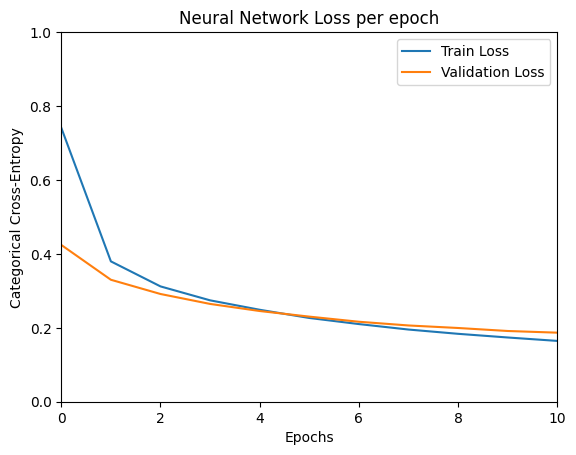

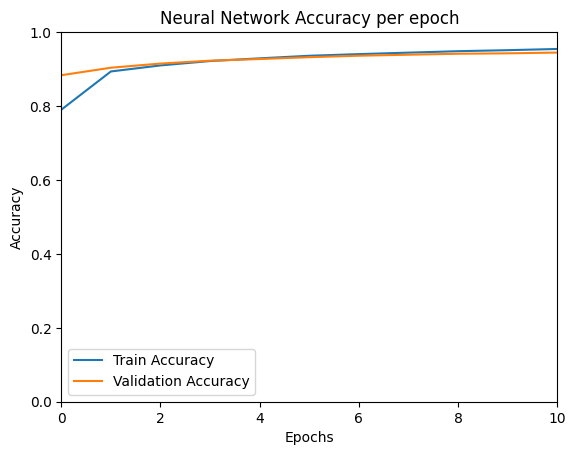

In [14]:
# printing the models accuracy and plotting the new model results

# implementing inference to extract the accuracy numbers
official_loss, official_accuracy = new_model.evaluate(x_test, y_test, verbose=0)
print(f"Official Test Accuracy: {official_accuracy:.4f}")
print(f"Official Test Loss: {official_loss:.4f}")

# plotting
train_loss = new_history.history['loss']
val_loss = new_history.history['val_loss']
train_acc = new_history.history['accuracy']
val_acc = new_history.history['val_accuracy']

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Neural Network Loss per epoch')
plt.ylabel('Categorical Cross-Entropy')
plt.xlabel('Epochs')
plt.xlim(0, epochs)
plt.ylim(0, 1)
plt.legend()
plt.show()

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Neural Network Accuracy per epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.xlim(0, epochs)
plt.ylim(0, 1)
plt.legend()
plt.show()

## 2. Validation: Show 1 misclassified digit from each class.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


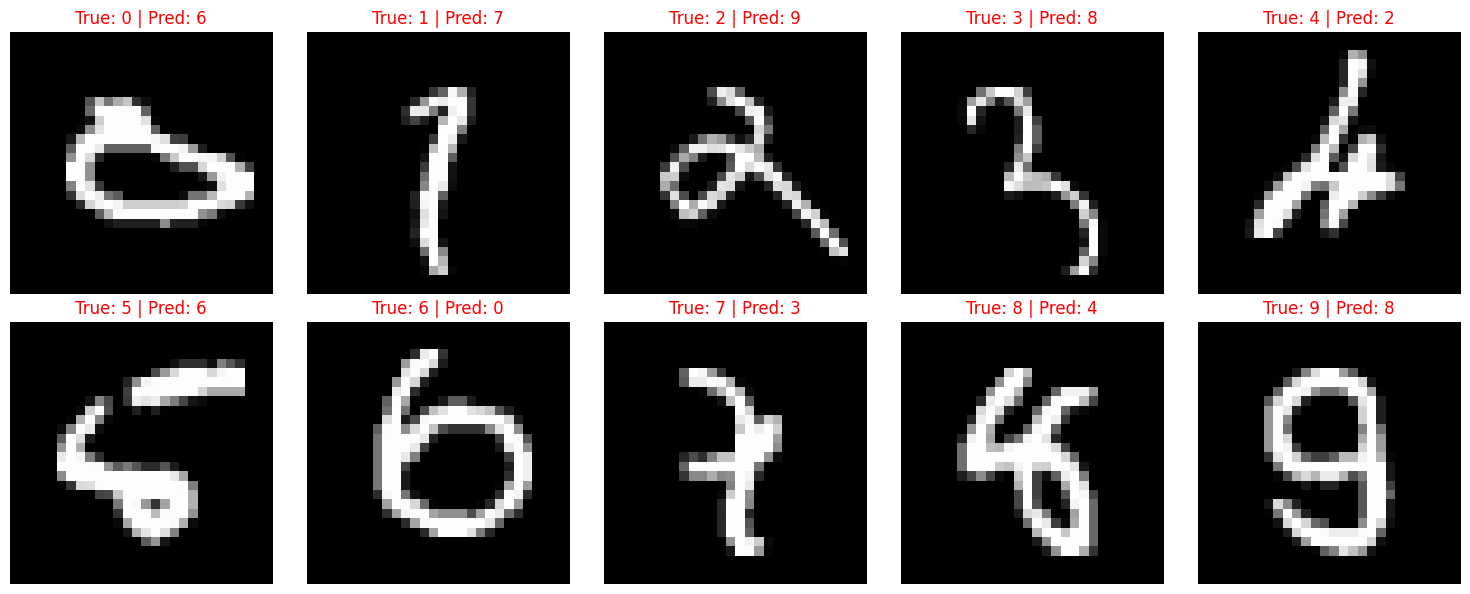

In [15]:
# Note that this task was performed based on the new model that was implemented on task1

# Generate probability matrices for the unseen test data
predictions = new_model.predict(x_test)

# Convert the 10-neuron output probabilities into single integer predictions from 0-9
# that way, the math/comparison can work between the two classes
predicted_classes = np.argmax(predictions, axis=1)

# Convert again the one-hot encoded targets back to integers for comparison
# (Because y_test was converted to shape (10000, 10) in the preprocessing step)
true_classes = np.argmax(y_test, axis=1)

# Finding every incident that the prediction doesnt match the true target
mistakes = np.where(predicted_classes != true_classes)[0]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
axes = axes.flatten()

for target_class in range(10):
    # Adding inside the current class only the mistakes that match the current digit we are examining isinde the for loop
    class_mistakes = [idx for idx in mistakes if true_classes[idx] == target_class]

    ax = axes[target_class]

    if class_mistakes:

        # takes the first mistake found because we only want one random incident
        idx = class_mistakes[0]

        # Reshaping the vector to two dimensions so it can be rendered as an image
        img = x_test[idx].reshape(28, 28)

        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {target_class} | Pred: {predicted_classes[idx]}', color='red')
    else:
        ax.set_title(f'Class {target_class}: 100% Accurate')

    ax.axis('off')

plt.tight_layout()
plt.show()

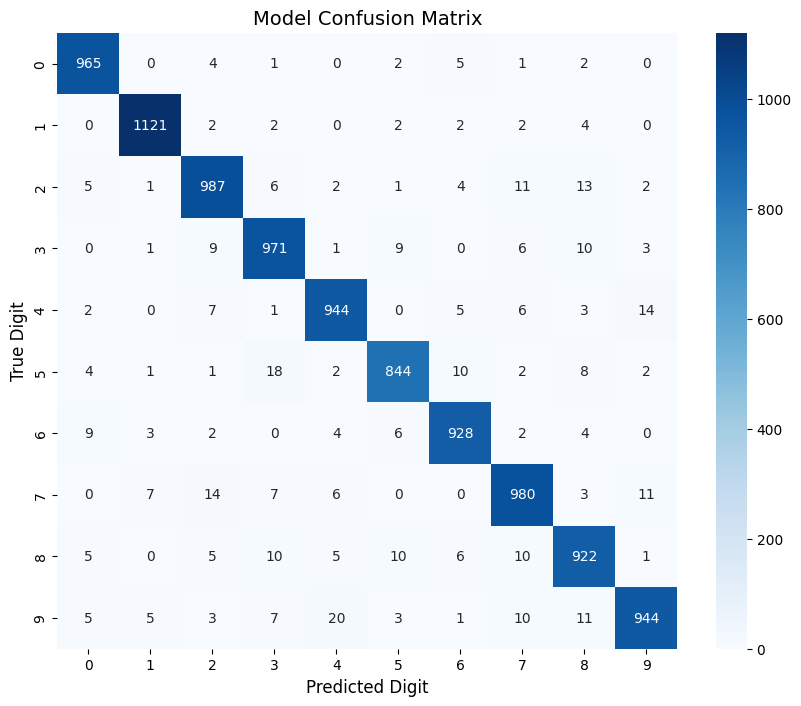

In [32]:
# Implementing a confusion map and a heatmap for the models predictions

import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generating the raw confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Creating the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))

plt.title('Model Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Digit', fontsize=12)
plt.ylabel('True Digit', fontsize=12)
plt.show()

## 3. Suggest & Implement workflow improvements, aside hyperparameter tuning. Can you think of any ways to increase the overall accuracy of the Neural Network?

In [21]:
# Improvement via normalization (for relu implementation)
# The reason this approach was choosen is examined in detail at the technical report
# The main change/addition in this task is the rescaling layer before the hidden layers, and the implementation of Batch Normalization

improved_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,), name='input'),

    # "Dummy Layer" we rescale the input data before passing them to the first hidden layer
    # (dividing them with 255)
    tf.keras.layers.Rescaling(scale=1./255, name='rescaling_layer'),

    # 1st Hidden Layer
    tf.keras.layers.Dense(units=512, activation='relu', name='hidden-1'),
    # Normalizing the data before passing them to the 2nd hidden layer
    tf.keras.layers.BatchNormalization(),

    # 2nd Hidden Layer
    tf.keras.layers.Dense(units=512, activation='relu', name='hidden-2'),
    # Normalizing the data before passing them to the output layer
    tf.keras.layers.BatchNormalization(),

    # Output Layer
    tf.keras.layers.Dense(units=10, activation='softmax', name='outputs')
])

improved_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

improved_model.compile(optimizer=improved_optimizer, loss=loss, metrics=metrics)

# Implementing Early Stopping to save computantional cost if the model isnt learning anymore
# this stops the overfitting proccess if the val loss stops getting better for a number of continuous iterations
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

improved_history = improved_model.fit(
    x=x_train,
    y=y_train,
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[early_stopping]
)



Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9232 - loss: 0.2533 - val_accuracy: 0.9631 - val_loss: 0.1166
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9725 - loss: 0.1014 - val_accuracy: 0.9704 - val_loss: 0.0925
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9855 - loss: 0.0611 - val_accuracy: 0.9744 - val_loss: 0.0818
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9933 - loss: 0.0386 - val_accuracy: 0.9764 - val_loss: 0.0759
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9968 - loss: 0.0251 - val_accuracy: 0.9770 - val_loss: 0.0733
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9988 - loss: 0.0168 - val_accuracy: 0.9773 - val_loss: 0.0720
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9995 - loss: 0.0118 - val_accuracy: 0.9783 - val_loss: 0.0716
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9998 - lo

Official Test Accuracy: 0.9783
Official Test Loss: 0.0716


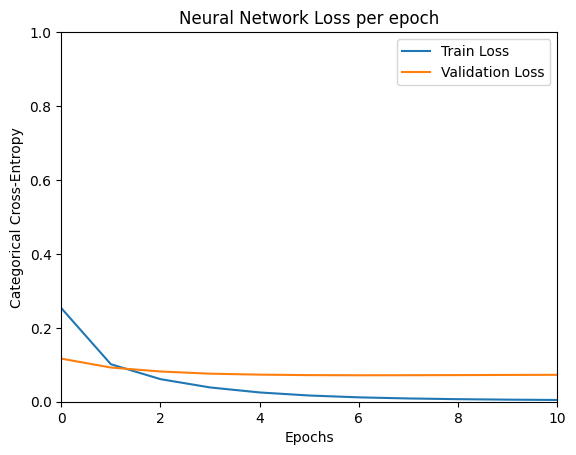

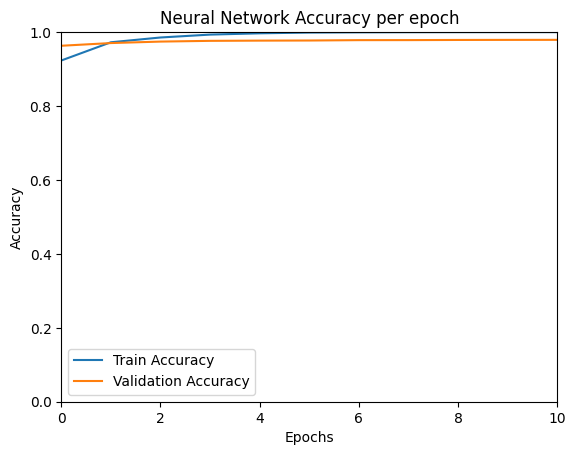

In [22]:
# printing the models accuracy and plotting the improved model results

# implementing inference to extract the accuracy numbers
official_loss, official_accuracy = improved_model.evaluate(x_test, y_test, verbose=0)
print(f"Official Test Accuracy: {official_accuracy:.4f}")
print(f"Official Test Loss: {official_loss:.4f}")

# plotting
train_loss = improved_history.history['loss']
val_loss = improved_history.history['val_loss']
train_acc = improved_history.history['accuracy']
val_acc = improved_history.history['val_accuracy']

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Neural Network Loss per epoch')
plt.ylabel('Categorical Cross-Entropy')
plt.xlabel('Epochs')
plt.xlim(0, epochs)
plt.ylim(0, 1)
plt.legend()
plt.show()

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Neural Network Accuracy per epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.xlim(0, epochs)
plt.ylim(0, 1)
plt.legend()
plt.show()

## 4. Upload the exercise in your GitHub repository. Google Colab can instantly deploy this notebook into a Github repository.

## 5. Write a README file in your github repository, explaining:

1. Your workflow
2. The final model architecture
3. The selected hyperparameters
4. Include the requirements.txt file, which shows the python version, as well as the library versions.

In [ ]:
!pip show tensorflow

Name: tensorflow
Version: 2.15.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tf_keras
